In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
from utils.analysis import vert_interp
from utils.constants import chamber_list_complete_dict

LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                    0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                    7.829766, 12.92532, 21.32647, 35.17762])
LEVGRND_I = np.append(np.insert(
    (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
THICKNESS = np.diff(LEVGRND_I)

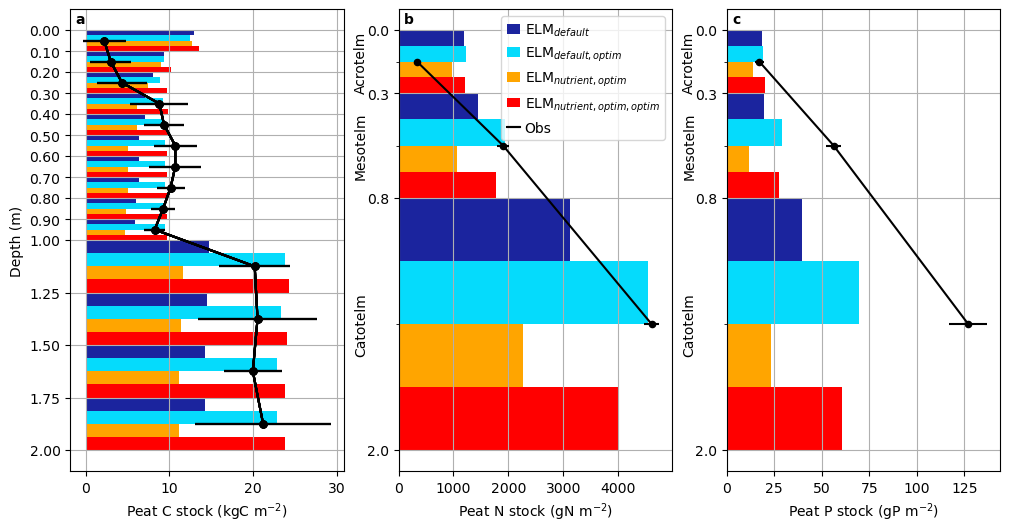

In [2]:
prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
ens_list = [None, 3067, 1185, 867]
name_list = ['ELM$_{default}$', 'ELM$_{default,optim}$',
             'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$']
color_list = ['#1b249e', '#05dbfc', '#ffa500', '#ff0000']
labs = 'abcdefgh'

fig, axes = plt.subplots(1, 3, figsize = (12, 6))

################################################
# Peat C stock
################################################
sampling_i = np.hstack([np.arange(0, 1., 0.1), np.arange(1, 2.1, 0.25)])
sampling = (sampling_i[1:] + sampling_i[:-1]) * 0.5
thickness = np.diff(sampling_i)
ax = axes.flat[0]
ax.text(0.02, 0.97, labs[0], transform = ax.transAxes, fontdict = {'weight': 'bold'})
h = []
for i, (prefix, ensemble_id, legend, color) in \
    enumerate(zip(prefix_list, ens_list, name_list, color_list)):

    if not "UQ" in prefix:
        rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                            f'plot07_US-SPR_ICB20TRCNPRDCTCBC', 'run')
    else:
        temp = f'P07'
        rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                            f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'g{ensemble_id:05d}', 
                            f'{chamber_list_complete_dict[temp]}')

    hr = xr.open_mfdataset(os.path.join(rundir, '*.h1.*.nc'))

    soc = (
        hr['LITR1C_vr'] + hr['LITR2C_vr'] + hr['LITR3C_vr'] + \
        hr['SOIL1C_vr'] + hr['SOIL2C_vr'] + hr['SOIL3C_vr'] + hr['SOIL4C_vr']
    ).mean(axis = 0)
    soc = soc[:, 0] * 0.64 + soc[:, 1] * 0.36

    # interpolate to sampling intervals
    soc = vert_interp(sampling, LEVGRND, soc.values.reshape(1, -1), False, sampling_i, LEVGRND_I)

    # gC m-3 => kgC m-2
    soc = soc.reshape(-1) * thickness / 1000

    bars = ax.barh(sampling_i[:-1] + thickness * i / len(prefix_list), soc, 
                    height=thickness / len(prefix_list), align='edge',
                    facecolor=color, edgecolor='none', linewidth=1)

    xobs = [2.229299363057326, 3.00955414012739, 4.347133757961783, 8.805732484076431, 
             9.363057324840764, 10.700636942675159, 10.700636942675159, 10.143312101910828, 
             9.251592356687897, 8.248407643312103, 20.17515923566879, 20.50955414012739,
             19.95222929936306, 21.17834394904459]
    ax.plot(xobs, sampling_i[:-1] + thickness/2,
            marker = 'o', ls = '-', color = 'k', markersize = 5)
    line = ax.errorbar(xobs, sampling_i[:-1] + thickness/2, 
                       xerr = [2.56369, 2.45223, 3.00955, 3.45541, 2.34076, 2.56369, 3.12102, 
                               1.67197, 1.44904, 1.22611, 4.23567, 7.13376, 3.45541, 8.13694], 
                       color = 'k', ecolor = 'k')

    h.append(bars[0])
    hr.close()
ax.invert_yaxis()
ax.set_yticks(sampling_i)
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Peat C stock (kgC m$^{-2}$)')
ax.grid(True)

################################################
# Peat N & P stock
################################################
sampling_i = np.array([0, 0.3, 0.8, 2])
sampling = (sampling_i[1:] + sampling_i[:-1]) * 0.5
thickness = np.diff(sampling_i)
for j, nu in enumerate(['N','P']):
    ax = axes.flat[j+1]
    ax.text(0.02, 0.97, labs[j+1], transform = ax.transAxes, fontdict = {'weight': 'bold'})
    h = []
    for i, (prefix, ensemble_id, legend, color) in \
        enumerate(zip(prefix_list, ens_list, name_list, color_list)):

        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot07_US-SPR_ICB20TRCNPRDCTCBC', 'run')
        else:
            temp = f'P07'
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'g{ensemble_id:05d}', 
                                f'{chamber_list_complete_dict[temp]}')

        hr = xr.open_mfdataset(os.path.join(rundir, '*.h1.*.nc'))

        soc = (
            hr[f'LITR1{nu}_vr'] + hr[f'LITR2{nu}_vr'] + hr[f'LITR3{nu}_vr'] + \
            hr[f'SOIL1{nu}_vr'] + hr[f'SOIL2{nu}_vr'] + hr[f'SOIL3{nu}_vr'] + hr[f'SOIL4{nu}_vr']
        ).mean(axis = 0)
        soc = soc[:, 0] * 0.64 + soc[:, 1] * 0.36

        # interpolate to sampling intervals
        soc = vert_interp(sampling, LEVGRND, soc.values.reshape(1, -1), False, 
                          sampling_i, LEVGRND_I)

        # gC m-3 => kgC m-2
        soc = soc.reshape(-1) * thickness

        bars = ax.barh(sampling_i[:-1] + thickness * i / len(prefix_list), soc, 
                       height = thickness / len(prefix_list), align='edge',
                       facecolor=color, edgecolor='none', linewidth=1)
        h.append(bars[0])

        hr.close()

    if j == 0:
        ax.scatter([337, 1903, 4604], [0.15, 0.55, 1.4], marker = 'o', color = 'k', s = 20)
        line = ax.errorbar([337, 1903, 4604], [0.15, 0.55, 1.4], xerr = [57, 115, 134], 
                            color = 'k', ecolor = 'k')
    else:
        ax.scatter([17.13, 56.22, 127], [0.15, 0.55, 1.4], marker = 'o', color = 'k', s = 20)
        ax.errorbar([17.13, 56.22, 127], [0.15, 0.55, 1.4], xerr = [2.24, 3.93, 10], 
                    color = 'k', ecolor = 'k')
    h.append(line)

    ax.invert_yaxis()
    ax.set_yticks(sampling_i)
    ax.set_xlabel(f'Peat {nu} stock (g{nu} m' + '$^{-2}$)')
    ax.set_yticks(sampling, minor=True)
    ax.set_yticklabels(['Acrotelm', 'Mesotelm', 'Catotelm'], minor=True, rotation = 90, 
                       verticalalignment='center')
    ax.tick_params(axis='y', which='minor', pad=20)
    ax.grid(True)
    if j == 0:
        ax.legend(h, name_list + ['Obs'], handlelength = 1, handletextpad=0.3)

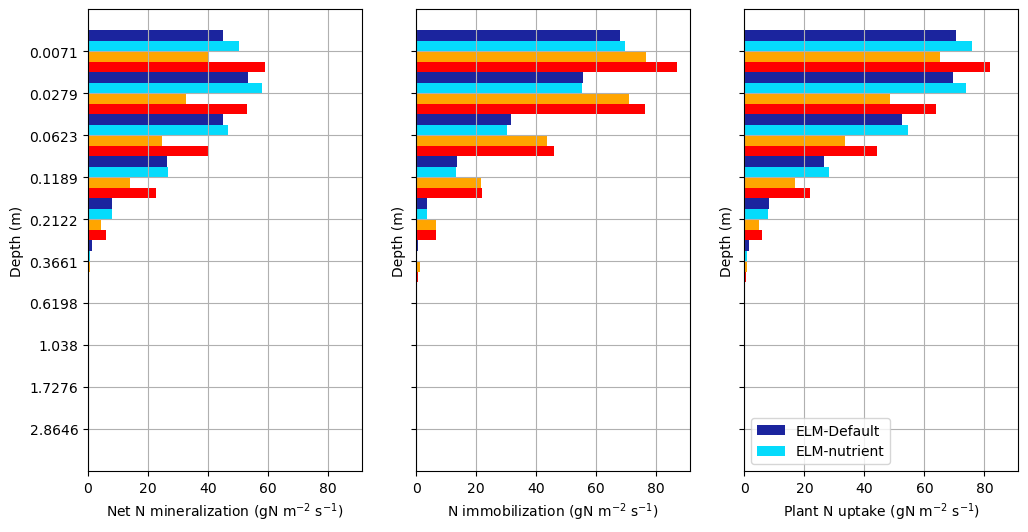

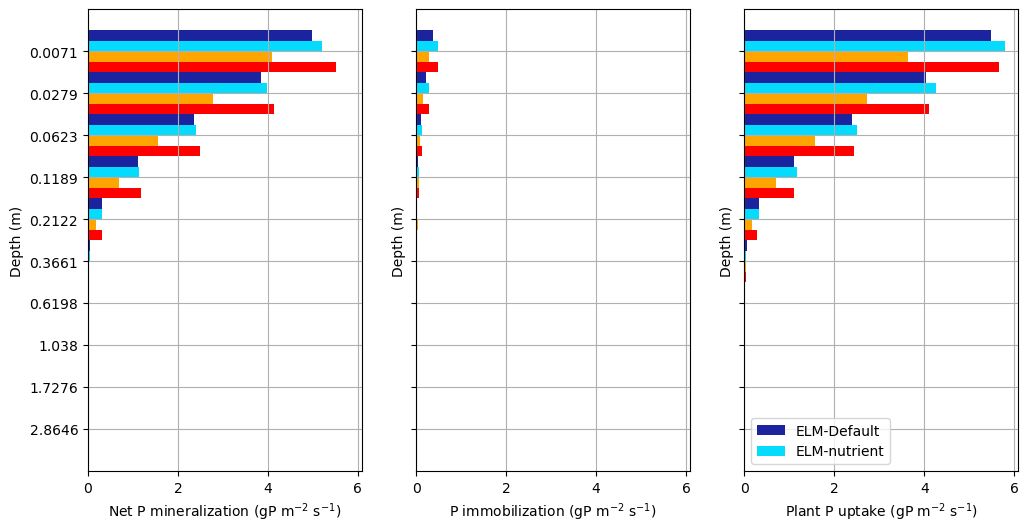

In [3]:
"""
Vertical distribution of supply and demand balance

Need to add more terms
"""
nu = 'N'
for nu in ['N','P']:
    xlabel_list = [f'Net {nu} mineralization (g{nu}', f'{nu} immobilization (g{nu}', 
                f'Plant {nu} uptake (g{nu}']

    if nu == 'N':
        varname_list = ['NET_NMIN_vr', 'ACTUAL_IMMOB_vr', 'SMINN_TO_PLANT_vr']
    else:
        varname_list = ['NET_PMIN_vr', 'ACTUAL_IMMOB_P_vr', 'SMINP_TO_PLANT_vr']

    fig, axes = plt.subplots(1, 3, figsize = (12, 6), sharey = True, sharex = True)
    for i, varname in enumerate(varname_list):
            ax = axes.flat[i]

            h = []
            for j, (prefix, ensemble_id, legend, color) in \
                enumerate(zip(prefix_list, ens_list, name_list, color_list)):

                if not "UQ" in prefix:
                    rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                        f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                        f'plot07_US-SPR_ICB20TRCNPRDCTCBC', 'run')
                else:
                    temp = f'P07'
                    rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                        f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'g{ensemble_id:05d}', 
                                        f'{chamber_list_complete_dict[temp]}')

                hr = xr.open_mfdataset(os.path.join(rundir, '*.h1.*.nc'))

                # gN m-3 s-1 => gN m-2 year-1
                net_nmin = hr[varname].mean(axis = 0) * 365 * 86400
                net_nmin = (net_nmin[:10,0] * 0.64 + net_nmin[:10,1] * 0.36) #  * THICKNESS[:10] / 1000

                bars = ax.barh(np.arange(10) + j/len(prefix_list), net_nmin, 
                               height=1/len(prefix_list), align='edge',
                               facecolor=color, edgecolor='none', linewidth=1)
                h.append(bars[0])

                hr.close()

            #ax.set_xscale('log')
            ax.set_yticks(np.arange(10) + 0.5)
            ax.set_yticklabels(np.around(LEVGRND[:10],4))
            ax.set_ylabel('Depth (m)')
            ax.set_xlabel(f'{xlabel_list[i]}' + ' m$^{-2}$ s$^{-1}$)')
            ax.grid(True)
            if i == 2:
                ax.invert_yaxis()
                ax.legend(h, ['ELM-Default', 'ELM-nutrient'])